---

# I. DATA COLLECTION

## 1.1 What subject is your data about?

Dataset này tập trung vào **âm nhạc toàn cầu trên nền tảng Spotify**, bao gồm thông tin về:
- **Tracks (bài hát)**: Tên bài hát, độ phổ biến, nội dung tường minh
- **Artists (nghệ sĩ)**: Tên nghệ sĩ, độ phổ biến, số lượng followers, thể loại âm nhạc
- **Albums**: Thông tin về album chứa các track
- **Temporal trends**: Xu hướng âm nhạc từ 2009 đến 2025

**Real-world context:**  
Dữ liệu này đại diện cho ngành công nghiệp âm nhạc kỹ thuật số toàn cầu, bao gồm sự thay đổi về sở thích người nghe, độ phổ biến của nghệ sĩ, xu hướng thể loại nhạc, và sự chuyển đổi từ các bài hát kinh điển (2009-2023) sang các bản nhạc hiện đại (2025). Spotify là một trong những nền tảng streaming âm nhạc lớn nhất thế giới với hơn 500 triệu người dùng.

## 1.2 What is the source of your data?

**Platform:** Kaggle  
**Dataset Name:** Spotify Global Music Dataset (2009–2025)  
**URL:** https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025/data  
**Author:** Warda Bilal  
**Publication Date:** November 2025 (last updated 20 days ago)  
**Original Source:** Spotify's Public API  

## 1.3 Is this data licensed for your use?

**License:** CC0: Public Domain  

**Educational Use:** Được phép  
Dataset này được phát hành dưới license CC0 (Public Domain), cho phép:
- Sử dụng cho mục đích giáo dục
- Sử dụng cho nghiên cứu
- Chia sẻ và phân phối

**Usage Restrictions:**  
- Không có hạn chế đặc biệt do thuộc giấy phép Public Domain
- Tác giả đã ghi rõ: "Used only for educational and research purposes" (Chỉ sử dụng cho mục đích giáo dục và nghiên cứu)
- Nên ghi nguồn: Dữ liệu được thu thập từ Spotify's public API bởi Warda Bilal trên Kaggle

## 1.4 How was this data collected?

**Collection Method:** Web scraping/API extraction
Dữ liệu được thu thập thông qua **Spotify's Public API**, một interface chính thức cho phép truy cập thông tin về tracks, artists, và albums.

**Target Population:**  
- **Đối tượng**: Các bài hát và nghệ sĩ trên Spotify
- **spotify_data clean.csv**: 8,582 bản nhạc hiện đại và nghệ sĩ gần đây (chủ yếu từ 2025)
- **track_data_final.csv**: 8,778 bản nhạc phổ biến và kinh điển từ 2009-2023 từ các nghệ sĩ nổi tiếng như Taylor Swift, Billie Eilish, Rihanna, v.v.

**Time Period:**  
- **2009-2023**: Historical data (track_data_final.csv)
- **2025**: Recent/contemporary data (spotify_data clean.csv)
Dữ liệu bao phủ từ 2009 đến năm 2025.

**Known Limitations:**
- Dữ liệu chỉ đại diện cho nền tảng Spotify, không phản ánh toàn bộ nền âm nhạc toàn cầu
- Dữ liệu phụ thuộc vào Spotify API availability
- Data các năm trước tập trung vào các nghệ sĩ nổi tiếng, có thể thiên về các nghệ sĩ phương Tây và bỏ qua các nghệ sĩ độc lập hoặc khu vực
- Độ phổ biến được đo bằng metrics của Spotify, có thể không phản ánh đầy đủ sự thành công thương mại hoặc ảnh hưởng văn hóa thực tế
- Không có dữ liệu rõ ràng cho năm 2024

## 1.5 Why did you choose this dataset?

**Group Interest:**
- Nhóm chúng em có mê với âm nhạc và công nghệ
- Spotify là nền tảng streaming mà tất cả thành viên trong nhóm đều sử dụng hàng ngày để giải trí
- Dataset này cung cấp cơ hội để hiểu sâu hơn về cách nền âm nhạc vận hành từ số liệu đã được cung cấp 

**Potential Questions & Insights:**
1. Làm thế nào độ phổ biến của nghệ sĩ ảnh hưởng đến độ phổ biến của tracks?
2. Các thể loại nhạc nào đang xu hướng trong những năm gần đây?
3. Có mối quan hệ nào giữa số lượng followers và track popularity?
4. Có thể dự đoán độ phổ biến của một bài hát dựa trên thông tin nghệ sĩ không?
5. Những yếu tố nào quyết định sự thành công của một nghệ sĩ?

**Practical Value:**
- Hiểu được xu hướng thị trường âm nhạc
- Hỗ trợ nghệ sĩ mới trong việc định hướng sự nghiệp
- Giúp nhà tài trợ đưa ra quyết định đầu tư
- Cải thiện recommendation systems

---

# II. DATA EXPLORATION

## 2.1 Dataset Overview

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Libraries imported successfully")

Libraries imported successfully


In [109]:
# Load datasets
df_2025 = pd.read_csv('../dataset/spotify_data clean.csv')
df_2009_2023 = pd.read_csv('../dataset/track_data_final.csv')

print(f"Dataset 2025 shape: {df_2025.shape}")
print(f"Dataset 2009-2023 shape: {df_2009_2023.shape}")

Dataset 2025 shape: (8582, 15)
Dataset 2009-2023 shape: (8778, 15)


### Basic Information

In [110]:
print("DATASET 2025 (spotify_data clean.csv) - BASIC INFORMATION")
print(f"\n1. Number of rows: {df_2025.shape[0]:,}")
print(f"2. Number of columns: {df_2025.shape[1]}")
print(f"3. Each row represents: One music track with its metadata")
print(f"4. Overall size: {df_2025.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n5. Column names and data types:")
print(df_2025.dtypes)

DATASET 2025 (spotify_data clean.csv) - BASIC INFORMATION

1. Number of rows: 8,582
2. Number of columns: 15
3. Each row represents: One music track with its metadata
4. Overall size: 4.56 MB

5. Column names and data types:
track_id               object
track_name             object
track_number            int64
track_popularity        int64
explicit                 bool
artist_name            object
artist_popularity       int64
artist_followers        int64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
track_duration_min    float64
dtype: object


In [111]:
print("DATASET 2009-2023 (track_data_final.csv) - BASIC INFORMATION")

print(f"\n1. Number of rows: {df_2009_2023.shape[0]:,}")
print(f"2. Number of columns: {df_2009_2023.shape[1]}")
print(f"3. Each row represents: One music track with its metadata")
print(f"4. Overall size: {df_2009_2023.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n5. Column names and data types:")
print(df_2009_2023.dtypes)

DATASET 2009-2023 (track_data_final.csv) - BASIC INFORMATION

1. Number of rows: 8,778
2. Number of columns: 15
3. Each row represents: One music track with its metadata
4. Overall size: 4.72 MB

5. Column names and data types:
track_id               object
track_name             object
track_number            int64
track_popularity        int64
track_duration_ms       int64
explicit                 bool
artist_name            object
artist_popularity     float64
artist_followers      float64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
dtype: object


### Data Integrity

In [112]:
print("DATASET 2025 - DATA INTEGRITY\n")

# Check duplicates
duplicates_by_id = df_2025[df_2025.duplicated(subset=['track_id'], keep=False)]
duplicates_first = df_2025[df_2025.duplicated(keep='first')]
completely_empty = df_2025[df_2025.isnull().all(axis=1)]

print(f"Duplicate rows (by track_id): {len(duplicates_by_id):,}")
print(f"Duplicate rows (exact): {len(duplicates_first):,}")
print(f"Completely empty rows: {len(completely_empty):,}")
print(f"Clean rows: {len(df_2025) - len(duplicates_first) - len(completely_empty):,} / {len(df_2025):,}")

if len(duplicates_first) > 0:
    print("\nSample duplicates:")
    print(duplicates_first[['track_id', 'track_name', 'artist_name']].head(3))

DATASET 2025 - DATA INTEGRITY

Duplicate rows (by track_id): 0
Duplicate rows (exact): 0
Completely empty rows: 0
Clean rows: 8,582 / 8,582


In [113]:
print("DATASET 2009-2023 - DATA INTEGRITY\n")

# Check duplicates
duplicates_by_id = df_2009_2023[df_2009_2023.duplicated(subset=['track_id'], keep=False)]
duplicates_first = df_2009_2023[df_2009_2023.duplicated(keep='first')]
completely_empty = df_2009_2023[df_2009_2023.isnull().all(axis=1)]

print(f"Duplicate rows (by track_id): {len(duplicates_by_id):,}")
print(f"Duplicate rows (exact): {len(duplicates_first):,}")
print(f"Completely empty rows: {len(completely_empty):,}")
print(f"Clean rows: {len(df_2009_2023) - len(duplicates_first) - len(completely_empty):,} / {len(df_2009_2023):,}")

if len(duplicates_first) > 0:
    print("\nSample duplicates:")
    print(duplicates_first[['track_id', 'track_name', 'artist_name']].head(3))

DATASET 2009-2023 - DATA INTEGRITY

Duplicate rows (by track_id): 0
Duplicate rows (exact): 0
Completely empty rows: 0
Clean rows: 8,778 / 8,778


### Column Inventory

In [114]:
print("DATASET 2025 - COLUMN INVENTORY\n")
print("Columns:")
for i, col in enumerate(df_2025.columns, 1):
    print(f"{i:2}. {col}")

DATASET 2025 - COLUMN INVENTORY

Columns:
 1. track_id
 2. track_name
 3. track_number
 4. track_popularity
 5. explicit
 6. artist_name
 7. artist_popularity
 8. artist_followers
 9. artist_genres
10. album_id
11. album_name
12. album_release_date
13. album_total_tracks
14. album_type
15. track_duration_min


In [115]:
print("DATASET 2009-2023 - COLUMN INVENTORY\n")
print("Columns:")
for i, col in enumerate(df_2009_2023.columns, 1):
    print(f"{i:2}. {col}")

DATASET 2009-2023 - COLUMN INVENTORY

Columns:
 1. track_id
 2. track_name
 3. track_number
 4. track_popularity
 5. track_duration_ms
 6. explicit
 7. artist_name
 8. artist_popularity
 9. artist_followers
10. artist_genres
11. album_id
12. album_name
13. album_release_date
14. album_total_tracks
15. album_type


### Column Definitions & Analysis

**Bảng tổng hợp các cột:**

| Column | Ý nghĩa | Relevent |
|--------|---------|----------|
| `track_id` | Mã định danh duy nhất của bài hát | ✓ |
| `track_name` | Tên bài hát | ✓ |
| `track_number` | Thứ tự bài hát trong album | ✗ |
| `track_popularity` | Độ phổ biến (0-100) | ✓ |
| `track_duration_ms` | Thời lượng (ms) - dataset 2009-2023 | ✓ |
| `track_duration_min` | Thời lượng (phút) - dataset 2025 | ✓ |
| `explicit` | Có nội dung tường minh không | ✓ |
| `artist_name` | Tên nghệ sĩ | ✓ |
| `artist_popularity` | Độ phổ biến nghệ sĩ (0-100) | ✓ |
| `artist_followers` | Số lượng người theo dõi nghệ sĩ | ✓ |
| `artist_genres` | Thể loại nhạc | ✓ |
| `album_id` | Mã định danh album | ✗ |
| `album_name` | Tên album | ✗ |
| `album_release_date` | Ngày phát hành | ✓ |
| `album_total_tracks` | Tổng số bài trong album | ? |
| `album_type` | Loại phát hành (album/single/compilation) | ? |

---

**Columns cần thiết:**

**1. Thông tin định danh:**
- **`track_id`**: Cần thiết để xác định duy nhất từng bài hát, loại bỏ duplicate, và join datasets
- **`track_name`**: Giúp hiểu được bài hát nào đang phân tích, có thể dùng cho text analysis sau này
- **`artist_name`**: Quan trọng để nhóm dữ liệu theo nghệ sĩ, phân tích nghệ sĩ nào thành công nhất

**2. Chỉ số độ phổ biến:**
- **`track_popularity`**: Đây là target variable chính - thước đo mức độ thành công của bài hát
- **`artist_popularity`**: Nghệ sĩ nổi tiếng thường ra bài hit dễ hơn, đây là predictor mạnh
- **`artist_followers`**: Số lượng fan base - có tương quan cao với khả năng bài hát viral

**3. Đặc điểm âm nhạc:**
- **`track_duration_ms` / `track_duration_min`**: Xu hướng hiện nay thiên về bài ngắn (2-3 phút). Có thể phân tích: bài ngắn hay dài được ưa chuộng hơn?
- **`explicit`**: Nội dung tường minh đang là xu hướng trong một số thể loại (rap, hip-hop). Đáng để phân tích trend theo thời gian
- **`artist_genres`**: Rất quan trọng - cho phép phân tích thể loại nào đang hot (pop, EDM, hip-hop...), dự đoán popularity theo genre

**4. Thông tin thời gian:**
- **`album_release_date`**: Cho phép time series analysis - xu hướng âm nhạc thay đổi như thế nào qua các năm? Có seasonal pattern không?

---

**Columns nên xóa:**

**1. `track_number`** - Thứ tự trong album
- Người nghe streaming ít quan tâm bài số mấy trong album
- Không ảnh hưởng đến độ phổ biến (bởi vì sẽ không có ai nói "tôi chỉ nghe bài số 3")

**2. `album_id`** - Mã định danh album  
- Chỉ hữu ích nếu phân tích theo album (không phải mục tiêu chính)
- Đã có `album_name` và `album_release_date` để tham chiếu nếu cần

**3. `album_name`** - Tên album
- Ít giá trị phân tích vì người nghe thời đại streaming ít quan tâm album
- Xu hướng là họ nghe từng bài riêng lẻ hoặc playlist, không nghe cả album

---

**Columns cần cân nhắc (tùy hướng phân tích):**

**1. `album_total_tracks`** - Số lượng bài trong album
- **Giữ nếu**: Muốn phân tích single vs album - single có marketing tập trung hơn nên có thể phổ biến hơn?
- **Xóa nếu**: Không nghiên cứu về chiến lược phát hành
- **Đề xuất**: Giữ lại tạm, vì có thể tạo feature mới: `is_single = (album_total_tracks == 1)`

**2. `album_type`** - Loại phát hành
- **Giữ nếu**: Muốn so sánh single vs album vs compilation
- **Xóa nếu**: Chỉ tập trung vào đặc điểm bài hát
- **Đề xuất**: Giữ lại vì có 3 giá trị duy nhất, dễ phân tích, có thể cho insight về chiến lược marketing

---

**Sự khác biệt giữa 2 datasets:**

- **Duration khác đơn vị**: Cần convert về cùng đơn vị (nên covert về phút)
- **Missing values**: Dataset 2025 thiếu `artist_genres` nhiều (39%) 
- **Data types**: Cần standardize `artist_popularity` và `artist_followers` về cùng kiểu khi merge

### Data Types Analysis

In [116]:
print("DATASET 2025")
print("Current data type of each column:")
for col in df_2025.columns:
    print(f"  {col:25} → {df_2025[col].dtype}")

DATASET 2025
Current data type of each column:
  track_id                  → object
  track_name                → object
  track_number              → int64
  track_popularity          → int64
  explicit                  → bool
  artist_name               → object
  artist_popularity         → int64
  artist_followers          → int64
  artist_genres             → object
  album_id                  → object
  album_name                → object
  album_release_date        → object
  album_total_tracks        → int64
  album_type                → object
  track_duration_min        → float64


In [117]:
print("DATASET 2009-2023")
print("Current data type of each column:")
for col in df_2009_2023.columns:
    print(f"  {col:25} → {df_2009_2023[col].dtype}")

DATASET 2009-2023
Current data type of each column:
  track_id                  → object
  track_name                → object
  track_number              → int64
  track_popularity          → int64
  track_duration_ms         → int64
  explicit                  → bool
  artist_name               → object
  artist_popularity         → float64
  artist_followers          → float64
  artist_genres             → object
  album_id                  → object
  album_name                → object
  album_release_date        → object
  album_total_tracks        → int64
  album_type                → object


### Inappropriate Data Types

1. **`artist_popularity` và `artist_followers`** - Không nhất quán giữa 2 datasets
   - Dataset 2025: `int64` 
   - Dataset 2009-2023: `float64` 
   - **Cần sửa**: Convert về `int64` cho cả 2 datasets

2. **`track_duration_ms` vs `track_duration_min`** - Khác đơn vị
   - Dataset 2025: `track_duration_min` (phút, float64)
   - Dataset 2009-2023: `track_duration_ms` (milliseconds, int64)
   - **Cần sửa**: Standardize về cùng đơn vị (phút)

In [118]:
# Dataset 2025: Convert artist_popularity and artist_followers to int64
df_2025['artist_popularity'] = df_2025['artist_popularity'].fillna(0).astype('int64')
df_2025['artist_followers'] = df_2025['artist_followers'].fillna(0).astype('int64')
# Dataset 2009-2023: Convert artist_popularity and artist_followers to int64
df_2009_2023['artist_popularity'] = df_2009_2023['artist_popularity'].fillna(0).astype('int64')
df_2009_2023['artist_followers'] = df_2009_2023['artist_followers'].fillna(0).astype('int64')
# Dataset 2009-2023: Convert track_duration_ms to track_duration_min (float64)
df_2009_2023['track_duration_min'] = df_2009_2023['track_duration_ms'] / 60000.0
df_2009_2023 = df_2009_2023.drop(columns=['track_duration_ms']) 

## 2.2 Numerical Columns Analysis

In [119]:
# Identify numerical columns
numerical_cols_2025 = df_2025.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols_2009 = df_2009_2023.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("DATASET 2025 - Numerical Columns:")
for i, col in enumerate(numerical_cols_2025, 1):
    print(f"  {i}. {col}")

print("\nDATASET 2009-2023 - Numerical Columns:")
for i, col in enumerate(numerical_cols_2009, 1):
    print(f"  {i}. {col}")

DATASET 2025 - Numerical Columns:
  1. track_number
  2. track_popularity
  3. artist_popularity
  4. artist_followers
  5. album_total_tracks
  6. track_duration_min

DATASET 2009-2023 - Numerical Columns:
  1. track_number
  2. track_popularity
  3. artist_popularity
  4. artist_followers
  5. album_total_tracks
  6. track_duration_min


### Distribution & Central Tendency

**Mục đích:** Hiểu numerical columns phân bố như thế nào

In [120]:
# Calculate: mean, median, standard deviation for both datasets
print(f"{'Column':<25} {'Dataset 2025':^45} {'Dataset 2009-2023':^45}")
print(f"{'':25} {'Mean':>15} {'Median':>15} {'Std Dev':>15} {'Mean':>15} {'Median':>15} {'Std Dev':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    mean_2025 = df_2025[col].mean()
    median_2025 = df_2025[col].median()
    std_2025 = df_2025[col].std()
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        mean_2009 = df_2009_2023[col].mean()
        median_2009 = df_2009_2023[col].median()
        std_2009 = df_2009_2023[col].std()
    else:
        mean_2009, median_2009, std_2009 = 0, 0, 0
    
    print(f"{col:<25} {mean_2025:>15.2f} {median_2025:>15.2f} {std_2025:>15.2f} {mean_2009:>15.2f} {median_2009:>15.2f} {std_2009:>15.2f}")

Column                                    Dataset 2025                                Dataset 2009-2023              
                                     Mean          Median         Std Dev            Mean          Median         Std Dev
album_total_tracks                  13.79           13.00           11.89           13.78           13.00           11.80
artist_followers              24034719.33      6105547.00     38031804.96     24343767.66      6223889.50     38132537.98
artist_popularity                   69.73           74.00           19.65           69.92           74.00           19.59
track_duration_min                   3.49            3.45            1.06            3.50            3.45            1.06
track_number                         5.77            4.00            6.05            5.75            4.00            6.02
track_popularity                    52.36           58.00           23.82           52.23           58.00           24.08


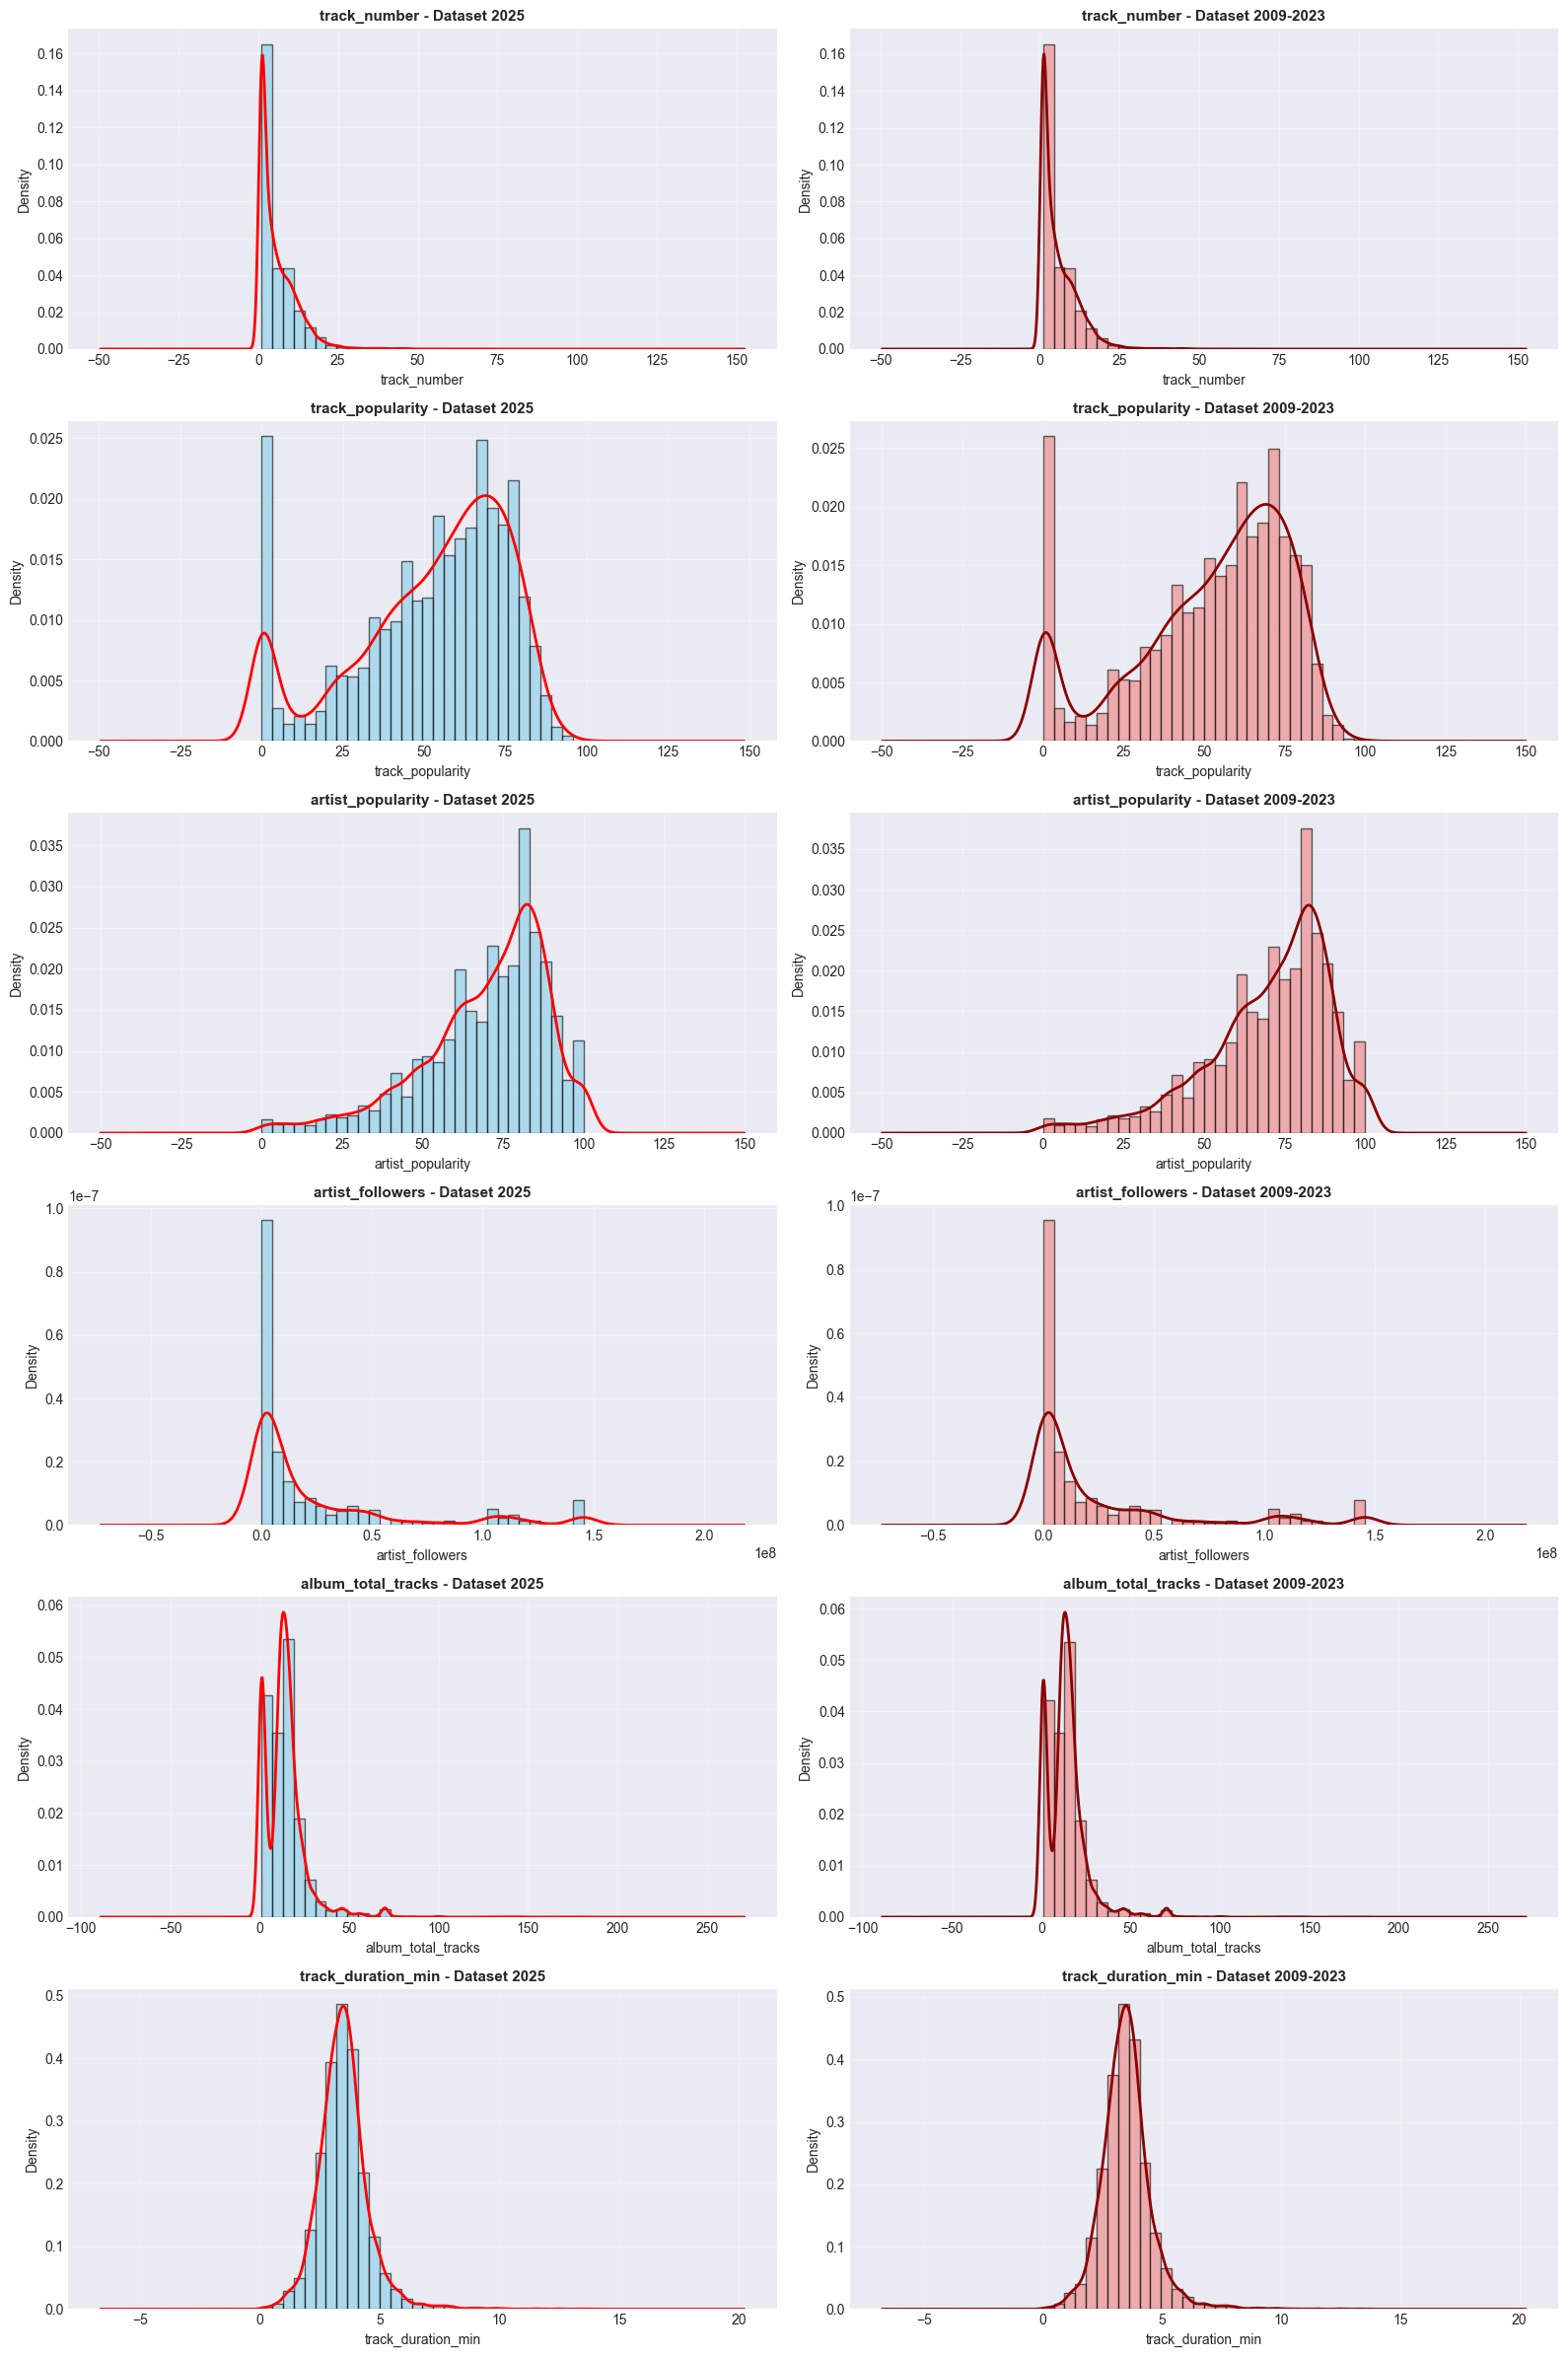

In [121]:
# Visualize distribution for each numerical column with histogram and KDE curve
fig, axes = plt.subplots(len(numerical_cols_2025), 2, figsize=(16, 4*len(numerical_cols_2025)))

for i, col in enumerate(numerical_cols_2025):
    # Dataset 2025
    data_2025 = df_2025[col].dropna()
    axes[i, 0].hist(data_2025, bins=30, edgecolor='black', alpha=0.6, density=True, color='skyblue')
    data_2025.plot(kind='kde', ax=axes[i, 0], color='red', linewidth=2)
    axes[i, 0].set_title(f'{col} - Dataset 2025', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel(col, fontsize=10)
    axes[i, 0].set_ylabel('Density', fontsize=10)
    axes[i, 0].grid(alpha=0.3)
    
    # Dataset 2009-2023 (now all columns have the same names)
    if col in numerical_cols_2009 or col == 'track_duration_min':
        data_2009 = df_2009_2023[col].dropna()
        axes[i, 1].hist(data_2009, bins=30, edgecolor='black', alpha=0.6, density=True, color='lightcoral')
        data_2009.plot(kind='kde', ax=axes[i, 1], color='darkred', linewidth=2)
        axes[i, 1].set_title(f'{col} - Dataset 2009-2023', fontsize=11, fontweight='bold')
        axes[i, 1].set_xlabel(col, fontsize=10)
        axes[i, 1].set_ylabel('Density', fontsize=10)
        axes[i, 1].grid(alpha=0.3)
    else:
        axes[i, 1].text(0.5, 0.5, 'Column not available\nin 2009-2023 dataset', 
                       ha='center', va='center', fontsize=12)
        axes[i, 1].set_title(f'{col} - Dataset 2009-2023 (N/A)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [122]:
# Determine distribution shape based on visual analysis and statistical measures
from scipy import stats

print(f"\n{'Column':<25} {'Dataset 2025':^45} {'Dataset 2009-2023':^45}")
print(f"{'':25} {'Skew':>10} {'Kurt':>10} {'Shape':<25} {'Skew':>10} {'Kurt':>10} {'Shape':<25}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    data_2025 = df_2025[col].dropna()
    skew_2025 = stats.skew(data_2025)
    kurt_2025 = stats.kurtosis(data_2025)
    
    if abs(skew_2025) < 0.5 and abs(kurt_2025) < 1:
        shape_2025 = "Normal"
    elif skew_2025 > 1:
        shape_2025 = "Right-skewed"
    elif skew_2025 < -1:
        shape_2025 = "Left-skewed"
    elif abs(kurt_2025) > 3:
        shape_2025 = "Heavy-tailed"
    elif abs(kurt_2025) < -1:
        shape_2025 = "Uniform-like"
    else:
        shape_2025 = "Moderate-skewed"
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        data_2009 = df_2009_2023[col].dropna()
        skew_2009 = stats.skew(data_2009)
        kurt_2009 = stats.kurtosis(data_2009)
        
        if abs(skew_2009) < 0.5 and abs(kurt_2009) < 1:
            shape_2009 = "Normal"
        elif skew_2009 > 1:
            shape_2009 = "Right-skewed"
        elif skew_2009 < -1:
            shape_2009 = "Left-skewed"
        elif abs(kurt_2009) > 3:
            shape_2009 = "Heavy-tailed"
        elif abs(kurt_2009) < -1:
            shape_2009 = "Uniform-like"
        else:
            shape_2009 = "Moderate-skewed"
    else:
        skew_2009, kurt_2009, shape_2009 = 0, 0, "N/A"
    
    print(f"{col:<25} {skew_2025:>10.3f} {kurt_2025:>10.3f} {shape_2025:<25} {skew_2009:>10.3f} {kurt_2009:>10.3f} {shape_2009:<25}")


Column                                    Dataset 2025                                Dataset 2009-2023              
                                Skew       Kurt Shape                           Skew       Kurt Shape                    
album_total_tracks             2.872     18.456 Right-skewed                   2.874     18.637 Right-skewed             
artist_followers               1.961      2.852 Right-skewed                   1.932      2.738 Right-skewed             
artist_popularity             -1.039      1.025 Left-skewed                   -1.060      1.094 Left-skewed              
track_duration_min             1.284      7.041 Right-skewed                   1.265      6.990 Right-skewed             
track_number                   2.653     16.498 Right-skewed                   2.656     16.571 Right-skewed             
track_popularity              -0.785     -0.238 Moderate-skewed               -0.779     -0.279 Moderate-skewed          


### Range & Outliers

**Mục đích:** Tìm giá trị bất thường và kiểm tra tính hợp lý

In [123]:
# Check min/max values for each numerical column - compare both datasets
print(f"{'Column':<25} {'Dataset 2025':^45} {'Dataset 2009-2023':^45}")
print(f"{'':25} {'Min':>15} {'Max':>15} {'Range':>15} {'Min':>15} {'Max':>15} {'Range':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025 - pandas functions skip NaN automatically
    min_2025 = df_2025[col].min()
    max_2025 = df_2025[col].max()
    range_2025 = max_2025 - min_2025
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        min_2009 = df_2009_2023[col].min()
        max_2009 = df_2009_2023[col].max()
        range_2009 = max_2009 - min_2009
    else:
        min_2009, max_2009, range_2009 = 0, 0, 0
    
    print(f"{col:<25} {min_2025:>15.2f} {max_2025:>15.2f} {range_2025:>15.2f} {min_2009:>15.2f} {max_2009:>15.2f} {range_2009:>15.2f}")

Column                                    Dataset 2025                                Dataset 2009-2023              
                                      Min             Max           Range             Min             Max           Range
album_total_tracks                   1.00          181.00          180.00            1.00          181.00          180.00
artist_followers                     0.00    145542136.00    145542136.00            0.00    145542136.00    145542136.00
artist_popularity                    0.00          100.00          100.00            0.00          100.00          100.00
track_duration_min                   0.07           13.51           13.44            0.00           13.52           13.52
track_number                         1.00          102.00          101.00            1.00          102.00          101.00
track_popularity                     0.00           99.00           99.00            0.00          100.00          100.00


**Phân tích Min/Max values:**

**Giá trị hợp lý:**
- `track_popularity`, `artist_popularity`: Nằm trong khoảng 0-100 (hợp lý theo định nghĩa của Spotify)
- `track_number`: Min = 1 là hợp lý (bài đầu tiên trong album)
- `album_total_tracks`: Min = 1 là hợp lý (album/single có ít nhất 1 bài)

**Giá trị cần kiểm tra:**
- `artist_followers`: Max lớn do có thể là nghệ sĩ nổi tiếng (Taylor Swift, BTS, etc.)
- `track_duration_min` / `track_duration_ms`: Max lớn do có thể là bài hát dài hoặc lỗi dữ liệu
- `track_number`, `album_total_tracks`: Max lớn nên cần kiểm tra xem có phải compilation album hay không

**Điểm bất thường:**
- Nếu `track_popularity` hoặc `artist_popularity` = 0 do Có thể là bài/nghệ sĩ mới hoặc không phổ biến
- Nếu `artist_followers` = 0 do có thể là lỗi dữ liệu hoặc nghệ sĩ không có followers

In [124]:
from scipy import stats as sp_stats

print(f"{'Column':<25} {'Dataset 2025':^55} {'Dataset 2009-2023':^55}")
print(f"{'':25} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>10} {'Upper':>10} {'Outliers':>10}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025 - quantile() skips NaN, but we need non-null count for percentage
    q1_2025 = df_2025[col].quantile(0.25)
    q3_2025 = df_2025[col].quantile(0.75)
    iqr_2025 = q3_2025 - q1_2025
    lower_2025 = q1_2025 - 1.5 * iqr_2025
    upper_2025 = q3_2025 + 1.5 * iqr_2025
    outliers_2025 = ((df_2025[col] < lower_2025) | (df_2025[col] > upper_2025)).sum()
    non_null_2025 = df_2025[col].notna().sum()
    outlier_pct_2025 = (outliers_2025 / non_null_2025) * 100 if non_null_2025 > 0 else 0
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        q1_2009 = df_2009_2023[col].quantile(0.25)
        q3_2009 = df_2009_2023[col].quantile(0.75)
        iqr_2009 = q3_2009 - q1_2009
        lower_2009 = q1_2009 - 1.5 * iqr_2009
        upper_2009 = q3_2009 + 1.5 * iqr_2009
        outliers_2009 = ((df_2009_2023[col] < lower_2009) | (df_2009_2023[col] > upper_2009)).sum()
        non_null_2009 = df_2009_2023[col].notna().sum()
        outlier_pct_2009 = (outliers_2009 / non_null_2009) * 100 if non_null_2009 > 0 else 0
    else:
        q1_2009, q3_2009, iqr_2009, lower_2009, upper_2009, outliers_2009, outlier_pct_2009 = 0, 0, 0, 0, 0, 0, 0
    
    print(f"{col:<25} {q1_2025:>10.1f} {q3_2025:>10.1f} {iqr_2025:>10.1f} {lower_2025:>10.1f} {upper_2025:>10.1f} {outliers_2025:>7}({outlier_pct_2025:>4.1f}%) {q1_2009:>10.1f} {q3_2009:>10.1f} {iqr_2009:>10.1f} {lower_2009:>10.1f} {upper_2009:>10.1f} {outliers_2009:>7}({outlier_pct_2009:>4.1f}%)")

Column                                         Dataset 2025                                          Dataset 2009-2023                   
                                  Q1         Q3        IQR      Lower      Upper   Outliers         Q1         Q3        IQR      Lower      Upper   Outliers
album_total_tracks               6.0       17.0       11.0      -10.5       33.5     379( 4.4%)        6.0       17.0       11.0      -10.5       33.5     380( 4.3%)
artist_followers            462320.0 27252551.0 26790231.0 -39723026.5 67437897.5    1044(12.2%)   512702.5 30550549.0 30037846.5 -44544067.2 75607318.8     999(11.4%)
artist_popularity               60.0       84.0       24.0       24.0      120.0     286( 3.3%)       60.0       84.0       24.0       24.0      120.0     289( 3.3%)
track_duration_min               2.9        4.0        1.1        1.2        5.7     358( 4.2%)        2.9        4.0        1.1        1.3        5.6     377( 4.3%)
track_number                     1.0  

**Phân tích Outliers:**

**IQR Method Interpretation:**
- **Lower Bound** = Q1 - 1.5 × IQR
- **Upper Bound** = Q3 + 1.5 × IQR
- Giá trị nào nằm ngoài khoảng [Lower, Upper] thì là outliers

**Outliers có thể là giá trị hợp lý:**
- `artist_followers`: Nghệ sĩ siêu nổi tiếng (Taylor Swift, BTS, The Weeknd) có số followers rất cao
- `track_duration_min/ms`: Một số bài hát thực sự dài (classical, progressive rock, live recordings)
- `album_total_tracks`: Compilation album, box sets có thể có rất nhiều tracks

**Outliers có thể là lỗi dữ liệu:**
- `track_number` hoặc `album_total_tracks` quá cao (> 100) 
- `track_popularity` hoặc `artist_popularity` = 0 liên tục 
- `track_duration` quá ngắn (< 30s) hoặc quá dài (> 30 phút)

**Cần cân nhắc:**
- Columns có tỷ lệ outliers > 10% cần recheck
- Xem xét kỹ từng context của outlier (tên bài, nghệ sĩ, album) để đưa ra quyết định

### Data Quality Check

**Mục đích:** Kiểm tra chất lượng dữ liệu số

In [125]:
# Calculate percentage of missing values for each numerical column
print(f"{'Column':<25} {'Dataset 2025':^30} {'Dataset 2009-2023':^30}")
print(f"{'':25} {'Missing':>15} {'Percent':>15} {'Missing':>15} {'Percent':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    missing_2025 = df_2025[col].isnull().sum()
    pct_2025 = (missing_2025 / len(df_2025)) * 100
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        missing_2009 = df_2009_2023[col].isnull().sum()
        pct_2009 = (missing_2009 / len(df_2009_2023)) * 100
    else:
        missing_2009, pct_2009 = 0, 0
    
    print(f"{col:<25} {missing_2025:>15,} {pct_2025:>14.2f}% {missing_2009:>15,} {pct_2009:>14.2f}%")

Column                             Dataset 2025                Dataset 2009-2023       
                                  Missing         Percent         Missing         Percent
album_total_tracks                      0           0.00%               0           0.00%
artist_followers                        0           0.00%               0           0.00%
artist_popularity                       0           0.00%               0           0.00%
track_duration_min                      0           0.00%               0           0.00%
track_number                            0           0.00%               0           0.00%
track_popularity                        0           0.00%               0           0.00%


**Phân tích Placeholder Values:**

**1. Giá trị 0 (Zero Values):**

**Hợp lý:**
- `track_popularity` = 0: Bài hát mới phát hành hoặc chưa được nghe nhiều → Giữ lại
- `artist_popularity` = 0: Nghệ sĩ mới, chưa có fan base → Giữ lại
- `artist_followers` = 0: Nghệ sĩ mới hoặc independent artist chưa có người theo dõi → Giữ lại (nhưng cần kiểm tra thêm)

**Không hợp lý (cần xử lý):**
- `track_number` = 0: Album luôn bắt đầu từ track 1, 0 là lỗi → Convert sang NaN hoặc 1
- `album_total_tracks` = 0: Album không thể có 0 bài, đây là lỗi → Convert sang NaN hoặc 1 (nếu là single)
- `track_duration_min` = 0: Bài hát không thể dài 0 phút → Đây là missing value, convert sang NaN

**Nghi ngờ (cần investigate):**
- Nếu `artist_followers` = 0 nhưng `artist_popularity` > 50 → Không logic, có thể là lỗi
- Nếu cả `track_popularity` và `artist_popularity` đều = 0 đồng thời → Nghi ngờ là placeholder

---

**2. Giá trị -1 (Negative One):**

**Pattern nhận biết:**
- Giá trị -1 thường được dùng trong database để đánh dấu "unknown" hoặc "not applicable"
- Không có column numerical nào trong dataset Spotify hợp lý với giá trị âm

**Quyết định:**
- Nếu xuất hiện -1 ở bất kỳ column nào thì là placeholder cho missing value
- Convert tất cả -1 thành NaN
- Xử lý như missing data

---

**3. Giá trị 999 (Sentinel Value):**

**Pattern nhận biết:**
- 999 thường được dùng làm "magic number" để đánh dấu missing value
- Đặc biệt nghi ngờ ở các column có giới hạn tự nhiên như `track_number`, `album_total_tracks`

**Hành động:**
- `track_number` = 999: Rất khó có album 999 tracks cho nên ta convert sang NaN
- `album_total_tracks` = 999: Compilation album lớn nhất cũng không quá 100 tracks nên cần phải check
- Nếu 999 xuất hiện nhiều lần ở cùng 1 column thì đó là placeholder

In [126]:
# Check for placeholder values (0, -1, 999, etc.)
print(f"{'Column':<25} {'Dataset 2025':^45} {'Dataset 2009-2023':^45}")
print(f"{'':25} {'Zeros':>15} {'(-1)':>15} {'(999)':>15} {'Zeros':>15} {'(-1)':>15} {'(999)':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    zeros_2025 = (df_2025[col] == 0).sum()
    negones_2025 = (df_2025[col] == -1).sum()
    nines_2025 = (df_2025[col] == 999).sum()
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        zeros_2009 = (df_2009_2023[col] == 0).sum()
        negones_2009 = (df_2009_2023[col] == -1).sum()
        nines_2009 = (df_2009_2023[col] == 999).sum()
    else:
        zeros_2009, negones_2009, nines_2009 = 0, 0, 0
    
    print(f"{col:<25} {zeros_2025:>15,} {negones_2025:>15,} {nines_2025:>15,} {zeros_2009:>15,} {negones_2009:>15,} {nines_2009:>15,}")

Column                                    Dataset 2025                                Dataset 2009-2023              
                                    Zeros            (-1)           (999)           Zeros            (-1)           (999)
album_total_tracks                      0               0               0               0               0               0
artist_followers                        8               0               0               9               0               0
artist_popularity                      25               0               0              28               0               0
track_duration_min                      0               0               0               2               0               0
track_number                            0               0               0               0               0               0
track_popularity                      503               0               0             521               0               0


**Phân tích Impossible Values:**

**Giá trị không hợp lệ cần kiểm tra:**
- `track_popularity`, `artist_popularity`: Phải nằm trong [0, 100]
- `artist_followers`, `album_total_tracks`, `track_number`: Không được âm
- `track_duration_min`: Phải > 0, hợp lý nằm trong [0.5, 30] phút

**Hành động:**
- Nếu có giá trị âm hoặc vượt quá giới hạn thì là lỗi dữ liệu, cần xử lý
- Giá trị 0 có thể hợp lý (bài/nghệ sĩ chưa phổ biến)
- Giá trị ngoài khoảng hợp lý cần kiểm tra lại

In [146]:
# Check for impossible values in numerical columns
print("VALUES OUTSIDE [0, 100]:")
for col in ['track_popularity', 'artist_popularity']:
    invalid_2025 = df_2025[(df_2025[col] < 0) | (df_2025[col] > 100)][col].count()
    invalid_2009 = df_2009_2023[(df_2009_2023[col] < 0) | (df_2009_2023[col] > 100)][col].count()
    print(f"  - {col}: {invalid_2025:,} (2025), {invalid_2009:,} (2009-2023)")

print("\nNEGATIVE VALUES:")
for col in ['artist_followers', 'album_total_tracks', 'track_number']:
    negative_2025 = df_2025[df_2025[col] < 0][col].count()
    if col in df_2009_2023.columns:
        negative_2009 = df_2009_2023[df_2009_2023[col] < 0][col].count()
        print(f"  - {col}: {negative_2025:,} (2025), {negative_2009:,} (2009-2023)")
    else:
        print(f"  - {col}: {negative_2025:,} (2025)")

print("\nDURATION ISSUES:")
col = 'track_duration_min'
zero_2025 = df_2025[df_2025[col] <= 0][col].count()
unreasonable_2025 = df_2025[(df_2025[col] > 0) & ((df_2025[col] < 0.5) | (df_2025[col] > 30))][col].count()
zero_2009 = df_2009_2023[df_2009_2023[col] <= 0][col].count()
unreasonable_2009 = df_2009_2023[(df_2009_2023[col] > 0) & ((df_2009_2023[col] < 0.5) | (df_2009_2023[col] > 30))][col].count()
print(f"  - Zero/negative duration: {zero_2025:,} (2025), {zero_2009:,} (2009-2023)")
print(f"  - Unreasonable duration (<0.5min or >30min): {unreasonable_2025:,} (2025), {unreasonable_2009:,} (2009-2023)")

VALUES OUTSIDE [0, 100]:
  - track_popularity: 0 (2025), 0 (2009-2023)
  - artist_popularity: 0 (2025), 0 (2009-2023)

NEGATIVE VALUES:
  - artist_followers: 0 (2025), 0 (2009-2023)
  - album_total_tracks: 0 (2025), 0 (2009-2023)
  - track_number: 0 (2025), 0 (2009-2023)

DURATION ISSUES:
  - Zero/negative duration: 0 (2025), 2 (2009-2023)
  - Unreasonable duration (<0.5min or >30min): 11 (2025), 11 (2009-2023)


**Phân tích Missing Values:**
- Columns nào có missing values nhiều nhất cần được xử lý
- Nếu missing > 30% thì cần cân nhắc loại bỏ hoặc imputation cẩn thận
- So sánh tỷ lệ missing giữa 2 datasets

## 2.3 Categorical Columns Analysis

**Mục đích:** Phân tích các cột phân loại

In [155]:
# Identify categorical columns
categorical_cols_2025 = df_2025.select_dtypes(include=['object']).columns.tolist()
categorical_cols_2009 = df_2009_2023.select_dtypes(include=['object']).columns.tolist()

print("DATASET 2025 - Categorical Columns:")
for i, col in enumerate(categorical_cols_2025, 1):
    print(f"  {i}. {col}")

print("\nDATASET 2009-2023 - Categorical Columns:")
for i, col in enumerate(categorical_cols_2009, 1):
    print(f"  {i}. {col}")

DATASET 2025 - Categorical Columns:
  1. track_id
  2. track_name
  3. artist_name
  4. artist_genres
  5. album_id
  6. album_name
  7. album_release_date
  8. album_type

DATASET 2009-2023 - Categorical Columns:
  1. track_id
  2. track_name
  3. artist_name
  4. artist_genres
  5. album_id
  6. album_name
  7. album_release_date
  8. album_type


### Value Distribution

**Mục đích:** Phân tích phân bố giá trị của từng categorical column

In [159]:
# Unique values count and top frequencies for each categorical column
print("DATASET 2025 - VALUE DISTRIBUTION\n")

# Prepare data for all categorical columns
all_top_values = {}
for col in categorical_cols_2025:
    top_10 = df_2025[col].value_counts().head(10)
    all_top_values[col] = top_10

# Print header
col_width = 35
header = f"{'Rank':<6}"
for col in categorical_cols_2025:
    header += f"{col[:30]:<{col_width}}"
print(header)
print(f"{'Unique:':<6}", end='')
for col in categorical_cols_2025:
    print(f"{df_2025[col].nunique():,} values{'':<{col_width-len(str(df_2025[col].nunique()))-8}}", end='')
print("\n")

# Print top 10 rows
for rank in range(10):
    print(f"#{rank+1:<5}", end='')
    for col in categorical_cols_2025:
        if rank < len(all_top_values[col]):
            value = list(all_top_values[col].index)[rank]
            count = all_top_values[col].iloc[rank]
            percentage = (count / len(df_2025)) * 100
            
            # Truncate long values
            display_value = str(value)[:20] + "..." if len(str(value)) > 20 else str(value)
            cell_content = f"{display_value} ({count:,}, {percentage:.1f}%)"
            
            # Truncate if still too long
            if len(cell_content) > col_width - 1:
                cell_content = cell_content[:col_width-4] + "..."
            
            print(f"{cell_content:<{col_width}}", end='')
        else:
            print(f"{'-':<{col_width}}", end='')
    print()

DATASET 2025 - VALUE DISTRIBUTION

Rank  track_id                           track_name                         artist_name                        artist_genres                      album_id                           album_name                         album_release_date                 album_type                         
Unique:8,582 values                       7,462 values                       2,547 values                       661 values                        5,205 values                       4,870 values                       2,384 values                       3 values                          

#1    3EJS5LyekDim1Tf5rBFm... (1, 0.0%)  Home (8, 0.1%)                     Taylor Swift (324, 3.8%)           soundtrack (345, 4.0%)             3FFGbUutKWN1c4f0CJR4... (70, 0.8%) Nevermind (Super Del... (70, 0.8%) 2010-01-01 (76, 0.9%)              album (5,856, 68.2%)               
#2    1oQW6G2ZiwMuHqlPpP27... (1, 0.0%)  Flowers (8, 0.1%)                  The Weeknd (141, 1.6%)      

In [160]:
print("DATASET 2009-2023 - VALUE DISTRIBUTION\n")

# Prepare data for all categorical columns
all_top_values = {}
for col in categorical_cols_2009:
    top_10 = df_2009_2023[col].value_counts().head(10)
    all_top_values[col] = top_10

# Print header
col_width = 35
header = f"{'Rank':<6}"
for col in categorical_cols_2009:
    header += f"{col[:30]:<{col_width}}"
print(header)
print(f"{'Unique:':<6}", end='')
for col in categorical_cols_2009:
    print(f"{df_2009_2023[col].nunique():,} values{'':<{col_width-len(str(df_2009_2023[col].nunique()))-8}}", end='')
print("\n")

# Print top 10 rows
for rank in range(10):
    print(f"#{rank+1:<5}", end='')
    for col in categorical_cols_2009:
        if rank < len(all_top_values[col]):
            value = list(all_top_values[col].index)[rank]
            count = all_top_values[col].iloc[rank]
            percentage = (count / len(df_2009_2023)) * 100
            
            # Truncate long values
            display_value = str(value)[:20] + "..." if len(str(value)) > 20 else str(value)
            cell_content = f"{display_value} ({count:,}, {percentage:.1f}%)"
            
            # Truncate if still too long
            if len(cell_content) > col_width - 1:
                cell_content = cell_content[:col_width-4] + "..."
            
            print(f"{cell_content:<{col_width}}", end='')
        else:
            print(f"{'-':<{col_width}}", end='')
    print()

DATASET 2009-2023 - VALUE DISTRIBUTION

Rank  track_id                           track_name                         artist_name                        artist_genres                      album_id                           album_name                         album_release_date                 album_type                         
Unique:8,778 values                       7,465 values                       2,548 values                       652 values                        5,317 values                       4,873 values                       2,390 values                       3 values                          

#1    6pymOcrCnMuCWdgGVTvU... (1, 0.0%)  Flowers (8, 0.1%)                  Taylor Swift (330, 3.8%)           [] (4,492, 51.2%)                  3FFGbUutKWN1c4f0CJR4... (70, 0.8%) Nevermind (Super Del... (70, 0.8%) 2010-01-01 (78, 0.9%)              album (6,022, 68.6%)               
#2    2lWc1iJlz2NVcStV5fbt... (1, 0.0%)  Sorry (8, 0.1%)                    The Weeknd (151, 1.7%) 

**Đánh giá về phần sẽ visualization:**

Các columns như `track_id`, `track_name`, `artist_name`, `album_id`, `album_name`, `artist_genres`, `album_release_date` có **quá nhiều unique values** (hàng nghìn giá trị) nên không phù hợp để visualize.

Chỉ visualize 2 columns có số lượng categories hợp lý:
- `explicit`: True/False (2 values)
- `album_type`: album/single/compilation (3 values)

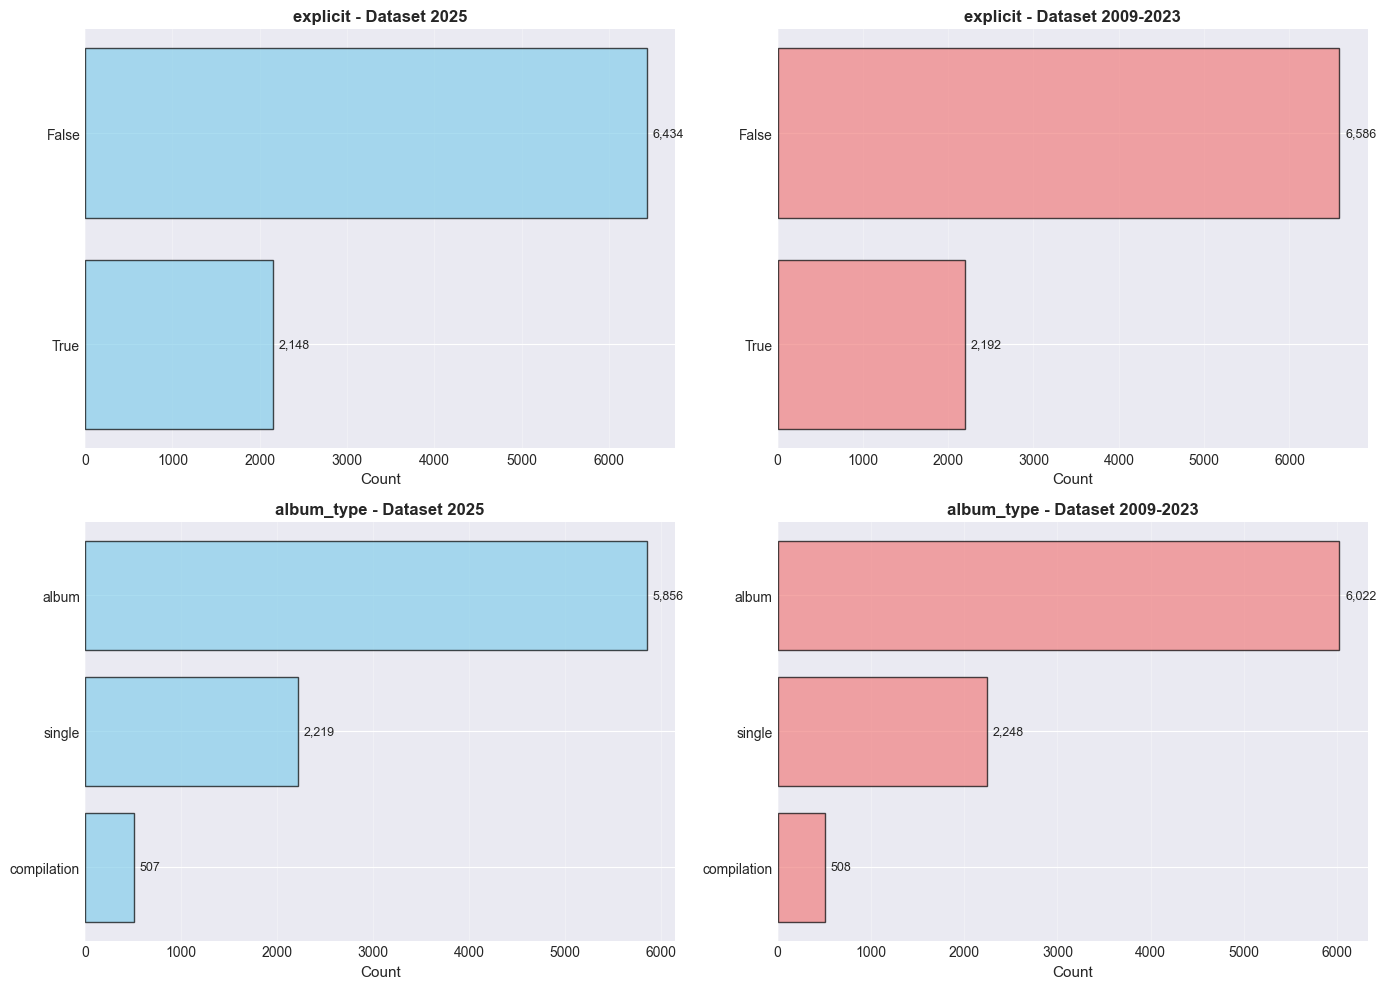

In [158]:
# Visualize distribution for key categorical columns
import matplotlib.pyplot as plt

# Focus on shorter categorical columns for visualization
viz_cols = ['explicit', 'album_type']  # Columns with fewer unique values

fig, axes = plt.subplots(len(viz_cols), 2, figsize=(14, 5*len(viz_cols)))

# Ensure axes is always 2D array
if len(viz_cols) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(viz_cols):
    # Dataset 2025
    # explicit is boolean, album_type is object - both can be visualized
    if col in df_2025.columns:
        top_values_2025 = df_2025[col].value_counts().head(10)
        axes[i, 0].barh(range(len(top_values_2025)), top_values_2025.values, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i, 0].set_yticks(range(len(top_values_2025)))
        axes[i, 0].set_yticklabels(top_values_2025.index, fontsize=10)
        axes[i, 0].set_xlabel('Count', fontsize=11)
        axes[i, 0].set_title(f'{col} - Dataset 2025', fontsize=12, fontweight='bold')
        axes[i, 0].grid(alpha=0.3, axis='x')
        axes[i, 0].invert_yaxis()  # Highest value on top
        
        # Add count labels
        for j, v in enumerate(top_values_2025.values):
            axes[i, 0].text(v + max(top_values_2025.values)*0.01, j, f'{v:,}', va='center', fontsize=9)
    
    # Dataset 2009-2023
    # explicit is boolean, album_type is object - both can be visualized
    if col in df_2009_2023.columns:
        top_values_2009 = df_2009_2023[col].value_counts().head(10)
        axes[i, 1].barh(range(len(top_values_2009)), top_values_2009.values, color='lightcoral', edgecolor='black', alpha=0.7)
        axes[i, 1].set_yticks(range(len(top_values_2009)))
        axes[i, 1].set_yticklabels(top_values_2009.index, fontsize=10)
        axes[i, 1].set_xlabel('Count', fontsize=11)
        axes[i, 1].set_title(f'{col} - Dataset 2009-2023', fontsize=12, fontweight='bold')
        axes[i, 1].grid(alpha=0.3, axis='x')
        axes[i, 1].invert_yaxis()  # Highest value on top
        
        # Add count labels
        for j, v in enumerate(top_values_2009.values):
            axes[i, 1].text(v + max(top_values_2009.values)*0.01, j, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Distribution Balance Analysis

**Mục đích:** Đánh giá mức độ cân bằng của từng categorical column

**1. Balanced Categories:**

**`explicit`:**
- Dataset 2025: False (6,434 - 75.0%), True (2,148 - 25.0%)
- Dataset 2009-2023: False (6,586 - 75.0%), True (2,192 - 25.0%)
- **Kết luận**: Tương đối cân bằng ở cả 2 datasets, tỷ lệ 3:1 (False:True)

**`album_type`:**
- Dataset 2025: album (5,856 - 68.2%), single (2,219 - 25.9%), compilation (507 - 5.9%)
- Dataset 2009-2023: album (6,022 - 68.6%), single (2,248 - 25.6%), compilation (508 - 5.8%)
- **Kết luận**: Cân bằng vừa phải, album chiếm đa số nhưng không quá áp đảo, tỷ lệ tương tự nhau giữa 2 datasets, không cần xử lý imbalance

**2. Imbalanced Categories:**

**Highly Fragmented (phân mảnh cao):**
- **`track_id`**: primary key, không dùng phân tích
- **`track_name`**: 7,462 unique, top value 8 lần, có thể có duplicates
- **`album_id`**, **`album_name`: top value 70 lần (0.8%)
- **`album_release_date`**: 2,384 unique, top value 76 lần

-> Đề xuất: Group theo năm hoặc tháng để phân tích xu hướng theo thời gian

**Moderately Concentrated (tập trung vừa phải):**
- **`artist_name`**: 2,547 unique, Taylor Swift (3.8%), The Weeknd (1.6%)

-> Đề xuất: Có thể group các nghệ sĩ ít bài hát thành nhóm "Others"
- **`artist_genres`**: 
  - Dataset 2025: 661 unique, "soundtrack" (4.0%), "pop" (3.8%)
  - Dataset 2009-2023: 652 unique, **51.2% missing values**

-> Đề xuất: Cần xử lý missing values trước khi sử dụng cho modeling

### Data Quality Check

**Mục đích:** Kiểm tra chất lượng dữ liệu categorical

In [161]:
# Missing values percentage for categorical columns
print("MISSING VALUES - CATEGORICAL COLUMNS\n")
print(f"{'Column':<25} {'Dataset 2025':^30} {'Dataset 2009-2023':^30}")
print(f"{'':25} {'Missing':>15} {'Percent':>15} {'Missing':>15} {'Percent':>15}")

for col in categorical_cols_2025:
    # Dataset 2025
    missing_2025 = df_2025[col].isnull().sum()
    pct_2025 = (missing_2025 / len(df_2025)) * 100
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        missing_2009 = df_2009_2023[col].isnull().sum()
        pct_2009 = (missing_2009 / len(df_2009_2023)) * 100
    else:
        missing_2009, pct_2009 = 0, 0
    
    print(f"{col:<25} {missing_2025:>15,} {pct_2025:>14.2f}% {missing_2009:>15,} {pct_2009:>14.2f}%")

MISSING VALUES - CATEGORICAL COLUMNS

Column                             Dataset 2025                Dataset 2009-2023       
                                  Missing         Percent         Missing         Percent
track_id                                0           0.00%               0           0.00%
track_name                              0           0.00%               2           0.02%
artist_name                             3           0.03%               4           0.05%
artist_genres                       3,361          39.16%               4           0.05%
album_id                                0           0.00%               0           0.00%
album_name                              0           0.00%               2           0.02%
album_release_date                      0           0.00%               0           0.00%
album_type                              0           0.00%               0           0.00%


In [169]:
# Check for inconsistencies in categorical values (case variations, whitespace)
print("INCONSISTENCY CHECK - CATEGORICAL COLUMNS\n")

# Store results to separate clean and problematic columns
clean_cols = []
issue_cols = []

for col in categorical_cols_2025:
    # Dataset 2025 - Check for case variations
    unique_values_2025 = df_2025[col].dropna().unique()
    lower_map_2025 = {}
    for val in unique_values_2025:
        val_str = str(val)
        lower_val = val_str.lower().strip()
        if lower_val not in lower_map_2025:
            lower_map_2025[lower_val] = []
        lower_map_2025[lower_val].append(val_str)
    
    case_issues_2025 = {k: v for k, v in lower_map_2025.items() if len(v) > 1}
    
    # Dataset 2009-2023 - Check for case variations
    case_issues_2009 = {}
    if col in df_2009_2023.columns:
        unique_values_2009 = df_2009_2023[col].dropna().unique()
        lower_map_2009 = {}
        for val in unique_values_2009:
            val_str = str(val)
            lower_val = val_str.lower().strip()
            if lower_val not in lower_map_2009:
                lower_map_2009[lower_val] = []
            lower_map_2009[lower_val].append(val_str)
        
        case_issues_2009 = {k: v for k, v in lower_map_2009.items() if len(v) > 1}
    
    # Categorize columns
    if not case_issues_2025 and not case_issues_2009:
        clean_cols.append(col)
    else:
        issue_cols.append({
            'col': col,
            'issues_2025': case_issues_2025,
            'issues_2009': case_issues_2009
        })

# Print clean columns first
print("✓ CLEAN COLUMNS (No case variations detected):")
print("-" * 80)
for col in clean_cols:
    print(f"  • {col}")

# Print problematic columns with details
print("\n\n⚠ COLUMNS WITH INCONSISTENCIES:")
print("-" * 80)

for item in issue_cols:
    col = item['col']
    case_issues_2025 = item['issues_2025']
    case_issues_2009 = item['issues_2009']
    
    print(f"\n{col.upper()}:")
    
    if case_issues_2025:
        print(f"  Dataset 2025: {len(case_issues_2025)} case variations")
        for lower_val, variations in list(case_issues_2025.items())[:3]:
            var_str = ', '.join([f"'{v}'" for v in variations[:4]])
            print(f"    → {var_str}")
    
    if case_issues_2009:
        print(f"  Dataset 2009-2023: {len(case_issues_2009)} case variations")
        for lower_val, variations in list(case_issues_2009.items())[:3]:
            var_str = ', '.join([f"'{v}'" for v in variations[:4]])
            print(f"    → {var_str}")

INCONSISTENCY CHECK - CATEGORICAL COLUMNS

✓ CLEAN COLUMNS (No case variations detected):
--------------------------------------------------------------------------------
  • track_id
  • artist_name
  • artist_genres
  • album_id
  • album_release_date
  • album_type


⚠ COLUMNS WITH INCONSISTENCIES:
--------------------------------------------------------------------------------

TRACK_NAME:
  Dataset 2025: 109 case variations
    → 'BLEED', 'Bleed'
    → 'superstar', 'SuperStar'
    → 'Part of Me', 'Part Of Me'
  Dataset 2009-2023: 110 case variations
    → 'blue', 'Blue', 'BLUE'
    → 'Pretty Please', 'PRETTY PLEASE'
    → 'DADDY', 'Daddy'

ALBUM_NAME:
  Dataset 2025: 41 case variations
    → 'BLEED', 'Bleed'
    → 'LEGENDARY', 'Legendary'
    → 'Golden Hour', 'golden hour'
  Dataset 2009-2023: 42 case variations
    → 'I Put a Spell on You', 'I Put A Spell On You'
    → 'blue', 'Blue'
    → 'Positions', 'positions'


In [171]:
# Check for unexpected/abnormal values in ALL categorical columns
print("UNEXPECTED VALUES CHECK\n")
print(f"{'Column':<25} {'Dataset 2025':^50} {'Dataset 2009-2023':^50}")
print("-" * 125)

for col in categorical_cols_2025:
    # Get unique values
    unique_2025 = df_2025[col].dropna().unique()
    
    # Display first few unique values
    if len(unique_2025) <= 5:
        display_2025 = str(list(unique_2025))
    else:
        display_2025 = f"{len(unique_2025):,} unique values (top 3: {list(unique_2025[:3])})"
    
    # Same for 2009-2023
    if col in df_2009_2023.columns:
        unique_2009 = df_2009_2023[col].dropna().unique()
        if len(unique_2009) <= 5:
            display_2009 = str(list(unique_2009))
        else:
            display_2009 = f"{len(unique_2009):,} unique values (top 3: {list(unique_2009[:3])})"
    else:
        display_2009 = "N/A"
    
    print(f"{col:<25} {display_2025[:48]:<50} {display_2009[:48]:<50}")

# Check for empty strings or whitespace-only values
print("\n\nEMPTY/WHITESPACE VALUES CHECK:")
print("-" * 80)

has_empty = False
for col in categorical_cols_2025:
    empty_2025 = df_2025[col].apply(lambda x: str(x).strip() == '' if pd.notna(x) else False).sum()
    
    if col in df_2009_2023.columns:
        empty_2009 = df_2009_2023[col].apply(lambda x: str(x).strip() == '' if pd.notna(x) else False).sum()
    else:
        empty_2009 = 0
    
    if empty_2025 > 0 or empty_2009 > 0:
        has_empty = True
        print(f"  {col}: {empty_2025:,} (2025), {empty_2009:,} (2009-2023)")

if not has_empty:
    print("  ✓ No empty or whitespace-only values found in any column")

UNEXPECTED VALUES CHECK

Column                                       Dataset 2025                                    Dataset 2009-2023                 
-----------------------------------------------------------------------------------------------------------------------------
track_id                  8,582 unique values (top 3: ['3EJS5LyekDim1Tf5rB   8,778 unique values (top 3: ['6pymOcrCnMuCWdgGVT  
track_name                7,462 unique values (top 3: ['Trippy Mane (ft. P   7,465 unique values (top 3: ['3', 'Clouds', 'For  
artist_name               2,547 unique values (top 3: ['Diplo', 'Yelawolf'   2,548 unique values (top 3: ['Britney Spears', '  
artist_genres             661 unique values (top 3: ['moombahton', 'countr   652 unique values (top 3: ["['pop']", "['stutter  
album_id                  5,205 unique values (top 3: ['5QRFnGnBeMGePBKF2x   5,317 unique values (top 3: ['325wcm5wMnlfjmKZ8P  
album_name                4,870 unique values (top 3: ['d00mscrvll, Vol. 1   4,87

In [173]:
# Identify rare categories (categories with very few observations)
print("RARE CATEGORIES (< 1% of total)\n")

for col in categorical_cols_2025:
    print(f"{col}:")
    
    # Dataset 2025
    value_counts_2025 = df_2025[col].value_counts()
    total_2025 = len(df_2025)
    rare_2025 = value_counts_2025[value_counts_2025 / total_2025 < 0.01]
    
    print(f"  Dataset 2025: {len(rare_2025):,} rare categories (out of {value_counts_2025.shape[0]:,} unique)")
    if len(rare_2025) > 0 and len(rare_2025) <= 10:
        print(f"    Examples: {list(rare_2025.head(5).index)}")
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        value_counts_2009 = df_2009_2023[col].value_counts()
        total_2009 = len(df_2009_2023)
        rare_2009 = value_counts_2009[value_counts_2009 / total_2009 < 0.01]
        
        print(f"  Dataset 2009-2023: {len(rare_2009):,} rare categories (out of {value_counts_2009.shape[0]:,} unique)")
        if len(rare_2009) > 0 and len(rare_2009) <= 10:
            print(f"    Examples: {list(rare_2009.head(5).index)}")
    
    print()

RARE CATEGORIES (< 1% of total)

track_id:
  Dataset 2025: 8,582 rare categories (out of 8,582 unique)
  Dataset 2009-2023: 8,778 rare categories (out of 8,778 unique)

track_name:
  Dataset 2025: 7,462 rare categories (out of 7,462 unique)
  Dataset 2009-2023: 7,465 rare categories (out of 7,465 unique)

artist_name:
  Dataset 2025: 2,542 rare categories (out of 2,547 unique)
  Dataset 2009-2023: 2,543 rare categories (out of 2,548 unique)

artist_genres:
  Dataset 2025: 650 rare categories (out of 661 unique)
  Dataset 2009-2023: 643 rare categories (out of 652 unique)

album_id:
  Dataset 2025: 5,205 rare categories (out of 5,205 unique)
  Dataset 2009-2023: 5,317 rare categories (out of 5,317 unique)

album_name:
  Dataset 2025: 4,870 rare categories (out of 4,870 unique)
  Dataset 2009-2023: 4,873 rare categories (out of 4,873 unique)

album_release_date:
  Dataset 2025: 2,384 rare categories (out of 2,384 unique)
  Dataset 2009-2023: 2,390 rare categories (out of 2,390 unique)

a

**Có nên gộp rare categories?**

** Các categories không nên gộp:**
- **`track_id`, `album_id`**: Primary keys, cần giữ nguyên
- **`artist_name`, `track_name`, `album_name`**: Identifiers quan trọng, không gộp
- **`album_release_date`**: Thời gian, nên group theo year/quarter thay vì gộp thành "Other"

**Các categoires có thể gộp:**
- **`artist_genres`**: Có thể nhóm các thể loại hiếm (<1%) vào "Other genres" hoặc group theo genre lớn hơn

## 2.4 Missing Data Analysis

**Mục đích:** Phân tích dữ liệu thiếu và patterns

### Overall Missing Values Summary

**Mục đích:** Tổng quan về missing values trong tất cả columns

In [ ]:
# Missing values summary
missing_summary_2025 = pd.DataFrame({
    'Column': df_2025.columns,
    'Missing_Count': df_2025.isnull().sum(),
    'Total_Rows': len(df_2025),
    'Missing_Percent': (df_2025.isnull().sum() / len(df_2025) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

missing_summary_2009 = pd.DataFrame({
    'Column': df_2009_2023.columns,
    'Missing_Count': df_2009_2023.isnull().sum(),
    'Total_Rows': len(df_2009_2023),
    'Missing_Percent': (df_2009_2023.isnull().sum() / len(df_2009_2023) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

print("\nDATASET 2025 - MISSING VALUES SUMMARY")
print(f"{'Column':<25} {'Missing Count':>15} {'Total Rows':>12} {'Missing %':>12}")
for _, row in missing_summary_2025.iterrows():
    status = "⚠" if row['Missing_Percent'] > 0 else "✓"
    print(f"{status} {row['Column']:<23} {row['Missing_Count']:>15,.0f} {row['Total_Rows']:>12,} {row['Missing_Percent']:>11.2f}%")

print("\nDATASET 2009-2023 - MISSING VALUES SUMMARY")
print(f"{'Column':<25} {'Missing Count':>15} {'Total Rows':>12} {'Missing %':>12}")
for _, row in missing_summary_2009.iterrows():
    status = "⚠" if row['Missing_Percent'] > 0 else "✓"
    print(f"{status} {row['Column']:<23} {row['Missing_Count']:>15,.0f} {row['Total_Rows']:>12,} {row['Missing_Percent']:>11.2f}%")

# Overall statistics
print("\nOVERALL STATISTICS")
total_cells_2025 = df_2025.shape[0] * df_2025.shape[1]
total_missing_2025 = df_2025.isnull().sum().sum()
print(f"Dataset 2025:")
print(f"  Total cells: {total_cells_2025:,}")
print(f"  Missing cells: {total_missing_2025:,}")
print(f"  Missing percentage: {(total_missing_2025/total_cells_2025*100):.2f}%")
print(f"  Columns with missing: {(missing_summary_2025['Missing_Count'] > 0).sum()}")

total_cells_2009 = df_2009_2023.shape[0] * df_2009_2023.shape[1]
total_missing_2009 = df_2009_2023.isnull().sum().sum()
print(f"\nDataset 2009-2023:")
print(f"  Total cells: {total_cells_2009:,}")
print(f"  Missing cells: {total_missing_2009:,}")
print(f"  Missing percentage: {(total_missing_2009/total_cells_2009*100):.2f}%")
print(f"  Columns with missing: {(missing_summary_2009['Missing_Count'] > 0).sum()}")

DATASET 2025 - MISSING VALUES SUMMARY
Column                      Missing Count   Total Rows    Missing %
--------------------------------------------------------------------------------
⚠ artist_genres                     3,361        8,582       39.16%
⚠ artist_name                           3        8,582        0.03%
✓ track_name                            0        8,582        0.00%
✓ track_number                          0        8,582        0.00%
✓ track_popularity                      0        8,582        0.00%
✓ explicit                              0        8,582        0.00%
✓ track_id                              0        8,582        0.00%
✓ artist_popularity                     0        8,582        0.00%
✓ artist_followers                      0        8,582        0.00%
✓ album_id                              0        8,582        0.00%
✓ album_name                            0        8,582        0.00%
✓ album_release_date                    0        8,582        0.0

### Missing Data Visualization

**Mục đích:** Visualize missing patterns với heatmap và bar chart

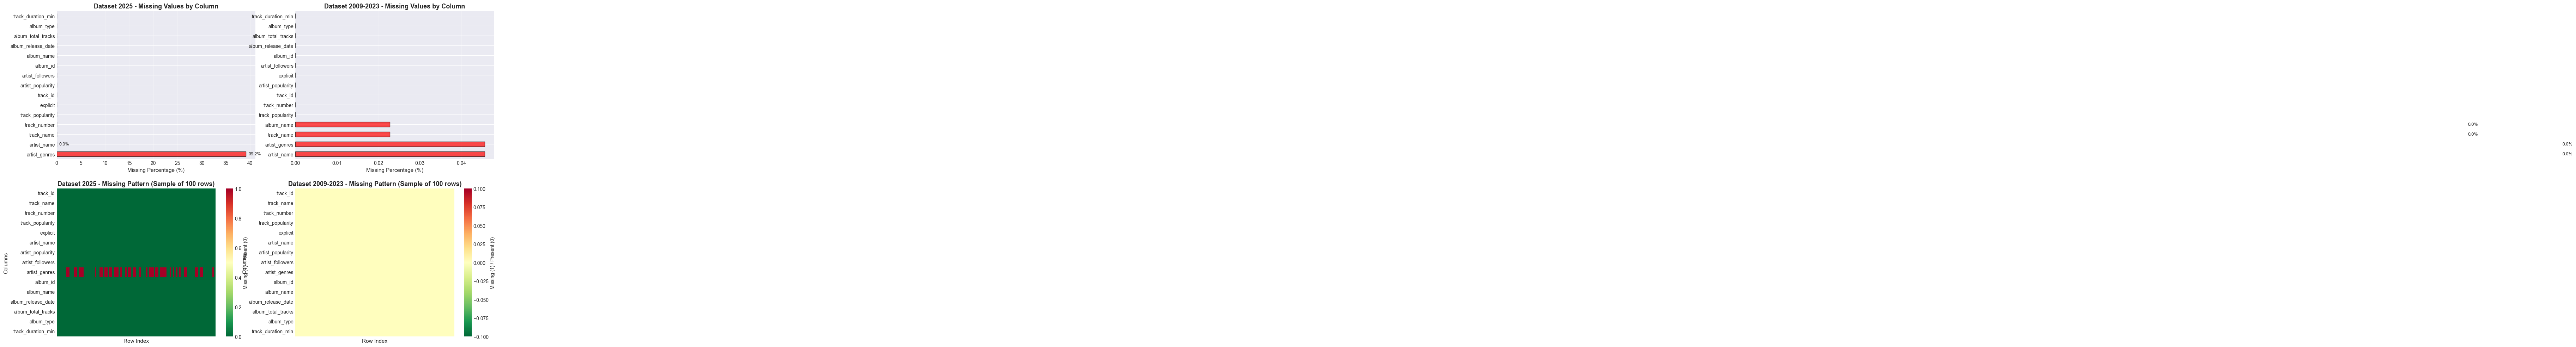

In [ ]:
# Visualize missing patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bar chart - Dataset 2025
ax1 = axes[0, 0]
missing_pct_2025 = (df_2025.isnull().sum() / len(df_2025) * 100).sort_values(ascending=False)
colors_2025 = ['red' if x > 0 else 'green' for x in missing_pct_2025]
missing_pct_2025.plot(kind='barh', ax=ax1, color=colors_2025, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Missing Percentage (%)', fontsize=11)
ax1.set_title('Dataset 2025 - Missing Values by Column', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3, axis='x')

for i, v in enumerate(missing_pct_2025):
    if v > 0:
        ax1.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Bar chart - Dataset 2009-2023
ax2 = axes[0, 1]
missing_pct_2009 = (df_2009_2023.isnull().sum() / len(df_2009_2023) * 100).sort_values(ascending=False)
colors_2009 = ['red' if x > 0 else 'green' for x in missing_pct_2009]
missing_pct_2009.plot(kind='barh', ax=ax2, color=colors_2009, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Missing Percentage (%)', fontsize=11)
ax2.set_title('Dataset 2009-2023 - Missing Values by Column', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3, axis='x')

for i, v in enumerate(missing_pct_2009):
    if v > 0:
        ax2.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Heatmap - Dataset 2025
ax3 = axes[1, 0]
sample_size = min(100, len(df_2025))
sample_indices = np.random.choice(df_2025.index, sample_size, replace=False)
missing_matrix_2025 = df_2025.loc[sample_indices].isnull().astype(int)

sns.heatmap(missing_matrix_2025.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing (1) / Present (0)'},
            ax=ax3, yticklabels=True, xticklabels=False)
ax3.set_title(f'Dataset 2025 - Missing Pattern (Sample of {sample_size} rows)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Row Index', fontsize=11)
ax3.set_ylabel('Columns', fontsize=11)

# Heatmap - Dataset 2009-2023
ax4 = axes[1, 1]
sample_size_2009 = min(100, len(df_2009_2023))
sample_indices_2009 = np.random.choice(df_2009_2023.index, sample_size_2009, replace=False)
missing_matrix_2009 = df_2009_2023.loc[sample_indices_2009].isnull().astype(int)

sns.heatmap(missing_matrix_2009.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing (1) / Present (0)'},
            ax=ax4, yticklabels=True, xticklabels=False)
ax4.set_title(f'Dataset 2009-2023 - Missing Pattern (Sample of {sample_size_2009} rows)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Row Index', fontsize=11)
ax4.set_ylabel('Columns', fontsize=11)

plt.tight_layout()
plt.show()

### Missing Data Pattern Analysis

**Mục đích:** Phân tích xem missing data có pattern hay random

In [ ]:
# Missing data pattern analysis
print("MISSING DATA PATTERN ANALYSIS\n")

# Rows with multiple missing values - Dataset 2025
print("ROWS WITH MULTIPLE MISSING VALUES (Dataset 2025):")
missing_per_row_2025 = df_2025.isnull().sum(axis=1)
print(f"Rows with 0 missing: {(missing_per_row_2025 == 0).sum():,} ({(missing_per_row_2025 == 0).sum()/len(df_2025)*100:.1f}%)")
print(f"Rows with 1 missing: {(missing_per_row_2025 == 1).sum():,} ({(missing_per_row_2025 == 1).sum()/len(df_2025)*100:.1f}%)")
print(f"Rows with 2+ missing: {(missing_per_row_2025 >= 2).sum():,} ({(missing_per_row_2025 >= 2).sum()/len(df_2025)*100:.1f}%)")
print(f"Max missing in a row: {missing_per_row_2025.max()}")

# Rows with multiple missing values - Dataset 2009-2023
print("\nROWS WITH MULTIPLE MISSING VALUES (Dataset 2009-2023):")
missing_per_row_2009 = df_2009_2023.isnull().sum(axis=1)
print(f"Rows with 0 missing: {(missing_per_row_2009 == 0).sum():,} ({(missing_per_row_2009 == 0).sum()/len(df_2009_2023)*100:.1f}%)")
print(f"Rows with 1 missing: {(missing_per_row_2009 == 1).sum():,} ({(missing_per_row_2009 == 1).sum()/len(df_2009_2023)*100:.1f}%)")
print(f"Rows with 2+ missing: {(missing_per_row_2009 >= 2).sum():,} ({(missing_per_row_2009 >= 2).sum()/len(df_2009_2023)*100:.1f}%)")
print(f"Max missing in a row: {missing_per_row_2009.max()}")

# Missing value co-occurrence analysis
print("\nMISSING VALUE CO-OCCURRENCE ANALYSIS:")

cols_with_missing_2025 = df_2025.columns[df_2025.isnull().any()].tolist()
if len(cols_with_missing_2025) > 1:
    print(f"\nDataset 2025 - Columns with missing: {cols_with_missing_2025}")
    missing_corr_2025 = df_2025[cols_with_missing_2025].isnull().corr()
    print("\nCorrelation matrix of missingness (1.0 = always missing together):")
    print(missing_corr_2025.round(3))
elif len(cols_with_missing_2025) == 1:
    print(f"\nDataset 2025 - Only one column has missing: {cols_with_missing_2025[0]}")
else:
    print("\nDataset 2025 - No missing values")

cols_with_missing_2009 = df_2009_2023.columns[df_2009_2023.isnull().any()].tolist()
if len(cols_with_missing_2009) > 1:
    print(f"\nDataset 2009-2023 - Columns with missing: {cols_with_missing_2009}")
    missing_corr_2009 = df_2009_2023[cols_with_missing_2009].isnull().corr()
    print("\nCorrelation matrix of missingness:")
    print(missing_corr_2009.round(3))
elif len(cols_with_missing_2009) == 1:
    print(f"\nDataset 2009-2023 - Only one column has missing: {cols_with_missing_2009[0]}")
else:
    print("\nDataset 2009-2023 - No missing values")

# Conclusion
print("\nCONCLUSION:")
if len(cols_with_missing_2025) > 0 or len(cols_with_missing_2009) > 0:
    print("Missing values detected. Check correlation matrix above.")
    print("High correlation (>0.5) = systematic missing pattern")
    print("Low correlation (<0.3) = random missing (MCAR)")
else:
    print("✓ No missing values - data is complete!")

MISSING DATA PATTERN ANALYSIS

1. ROWS WITH MULTIPLE MISSING VALUES (Dataset 2025):
--------------------------------------------------------------------------------
Rows with 0 missing: 5,221 (60.8%)
Rows with 1 missing: 3,358 (39.1%)
Rows with 2+ missing: 3 (0.0%)
Max missing in a row: 2

2. ROWS WITH MULTIPLE MISSING VALUES (Dataset 2009-2023):
--------------------------------------------------------------------------------
Rows with 0 missing: 8,772 (99.9%)
Rows with 1 missing: 0 (0.0%)
Rows with 2+ missing: 6 (0.1%)
Max missing in a row: 2

3. MISSING VALUE CO-OCCURRENCE ANALYSIS:
--------------------------------------------------------------------------------

Dataset 2025 - Columns with missing values: ['artist_name', 'artist_genres']

Correlation matrix of missingness (1.0 = always missing together):
               artist_name  artist_genres
artist_name           1.00           0.02
artist_genres         0.02           1.00

Dataset 2009-2023 - Columns with missing values: ['tra

## 2.5 Relationships & Correlations

**Mục đích:** Tìm mối quan hệ giữa các biến

In [130]:
# TODO: Calculate correlation matrix
# TODO: Create correlation heatmap
# TODO: Cross-tabulations for categorical variables

## 2.6 Initial Observations & Insights

**Mục đích:** Tóm tắt phát hiện chính

**Key Observations:**

1. [To be filled after exploration]
2. [To be filled after exploration]
3. [To be filled after exploration]

**Data Quality Issues:**

- [To be filled after exploration]

**Preprocessing Steps Needed:**

- [To be filled after exploration]

**Interesting Patterns:**

- [To be filled after exploration]

---

# 3. QUESTION FORMULATION

Dựa trên quá trình khám phá dữ liệu, nhóm chúng em đưa ra 6 câu hỏi nghiên cứu sau:

## Question 1: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Phạm Phú Hòa

## Question 2: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Phạm Phú Hòa

## Question 3: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Trần Chí Nguyên

## Question 4: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Trần Chí Nguyên

## Question 5: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Nguyễn Lâm Phú Quý

## Question 6: [Title] - MACHINE LEARNING MODEL

**The Question:**  
[To be filled - Must require ML model]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Nguyễn Lâm Phú Quý

---

# 4. DATA ANALYSIS

## Question 1: [Title]

### A. Preprocessing

In [131]:
# TODO: Implement preprocessing steps

### B. Analysis

In [132]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 2: [Title]

### A. Preprocessing

In [133]:
# TODO: Implement preprocessing steps

### B. Analysis

In [134]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 3: [Title]

### A. Preprocessing

In [135]:
# TODO: Implement preprocessing steps

### B. Analysis

In [136]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 4: [Title]

### A. Preprocessing

In [137]:
# TODO: Implement preprocessing steps

### B. Analysis

In [138]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 5: [Title]

### A. Preprocessing

In [139]:
# TODO: Implement preprocessing steps

### B. Analysis

In [140]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 6: [Title] - MACHINE LEARNING MODEL

### A. Preprocessing & Feature Engineering

In [141]:
# TODO: Implement preprocessing steps
# TODO: Feature engineering
# TODO: Train-test split

### B. Model Training & Evaluation

In [142]:
# TODO: Train multiple models (at least 2)
# TODO: Evaluate models
# TODO: Compare performance
# TODO: Feature importance analysis

### C. Results & Interpretation

[To be filled with findings]

---

# 5. PROJECT SUMMARY

## 5.1 Key Findings

**Top 3-5 Most Important Insights:**

1. [To be filled]
2. [To be filled]
3. [To be filled]
4. [To be filled]
5. [To be filled]

**Most Interesting/Surprising Discovery:**

[To be filled]

## 5.2 Limitations

**Dataset Limitations:**
- [To be filled]

**Analysis Limitations:**
- [To be filled]

**Scope Limitations:**
- [To be filled]

# Calculate percentage of missing values for each numerical column
print(f"{'Column':<25} {'Dataset 2025':^30} {'Dataset 2009-2023':^30}")
print(f"{'':25} {'Missing':>15} {'Percent':>15} {'Missing':>15} {'Percent':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    missing_2025 = df_2025[col].isnull().sum()
    pct_2025 = (missing_2025 / len(df_2025)) * 100
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        missing_2009 = df_2009_2023[col].isnull().sum()
        pct_2009 = (missing_2009 / len(df_2009_2023)) * 100
    else:
        missing_2009, pct_2009 = 0, 0
    
    print(f"{col:<25} {missing_2025:>15,} {pct_2025:>14.2f}% {missing_2009:>15,} {pct_2009:>14.2f}%")

**Phân tích Missing Values:**

**Dataset 2025:**
- Columns nào có missing values nhiều nhất cần được xử lý
- Nếu missing > 30% thì cần cân nhắc loại bỏ hoặc imputation cẩn thận

**Dataset 2009-2023:**
- So sánh tỷ lệ missing với Dataset 2025
- Xác định pattern: missing có theo quy luật không?

**Chiến lược xử lý:**
- Missing < 5%: Có thể drop hoặc impute bằng median/mean
- Missing 5-30%: Nên impute (median cho skewed, mean cho normal)
- Missing > 30%: Cân nhắc loại bỏ column hoặc dùng advanced imputation

---

# 6. INDIVIDUAL REFLECTIONS

## Phạm Phú Hòa (23122030)

### Challenges & Difficulties Encountered

[To be filled]

### Learning & Growth

[To be filled]

### What Surprised Me Most

[To be filled]

## Trần Chí Nguyên (23122044)

### Challenges & Difficulties Encountered

[To be filled]

### Learning & Growth

[To be filled]

### What Surprised Me Most

[To be filled]

## Nguyễn Lâm Phú Quý (23122048)

### Challenges & Difficulties Encountered

[To be filled]

### Learning & Growth

[To be filled]

### What Surprised Me Most

[To be filled]

---

# END OF NOTEBOOK

**Date Created:** December 1, 2025  
**Last Updated:** December 1, 2025  
**Version:** 1.0